# STOR 235 — Lab 4

This lab focuses on two basic applications of principal component analysis.

## Instructions

There are two parts to this lab:



1.   Image compression;
2.   MNIST visualization.


Each part will be composed of a number of tasks for you to complete. The tasks are labeled in bold as **Problem 1**, **Problem 2**, and so on. Please make sure that you do not forget to complete any of the problems. Each problem will be worth 5 points.

There is a single code block in under this introductory material that imports various things you will use later. Please run it.

## Important Information About Submitting Your Assignment

 Please upload your assignment as an executable python notebook.


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage import io
from urllib.request import urlopen
from io import BytesIO
from PIL import Image
import requests
from sklearn.metrics import mean_squared_error
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# Set the style for plots
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)


# Part 1: Image Compression


The following code takes an image, converts it to a array of values between 0 and 255, with each value in the array denoting the color of a pixel, and displays it. Larger values denote brighter pixels. It also prints the dimension of the image.

**Problem 1** Load one of the photos provided.  If you are on CoLab you will need to first upload the file

Image shape: (695, 1080)


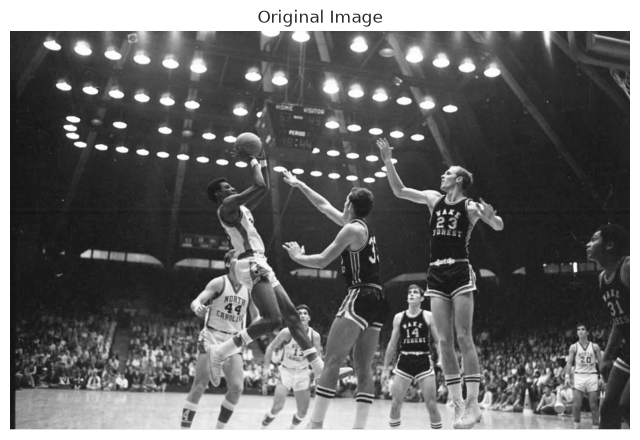

In [25]:
# 1. Download the image and convert to numpy array
# Convert to grayscale
X = Image.open('235_Lab_5_bball.jpg').convert('L')  
X = np.array(X)
X_float = X.astype(float)
print(f"Image shape: {X.shape}")

# Display the original image
plt.figure(figsize=(8, 8))
plt.imshow(X_float, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()




The next line prints the numerical values in the array.

In [26]:
print(X_float)

[[ 48.  46.  45. ...  59.  58.  58.]
 [ 49.  47.  46. ...  60.  58.  58.]
 [ 51.  49.  47. ...  61.  59.  59.]
 ...
 [  8.   8.   8. ...  91.  81.  72.]
 [ 94.  94.  94. ... 147. 141. 137.]
 [254. 254. 254. ... 255. 253. 252.]]


We now perform PCA following the recipe presented in class, and recorded in the notes. We treat the rows of the matrix as the given collection of data vectors that we want to compress. (Compare the definition of X here to the definition in the notes.)

Try to follow how the steps here relate to the steps in the notes.

The function `linalg.eigh` is a function from the numpy library that returns the eigenvalues and eigenvectors of a symemtric matrix. The eigenvectors are returned as a matrix where the first column corresponds to the first eigenvalue, the second column corresponds to the second eigenvalue, and so on. This is why we access the first eigenvector using `eigenvectors[:, 0]`, which is a way to refer to the first column of the array `eigenvectors`.

**Problem 2** Fill in the missing code: center the data and print the mean, compute the covariance matrix and print its shape, and find the eigenvalues and eigenvectors.

In [27]:
# 2. Perform PCA step by step

# --- fill in missing code

# Center the matrix 
X_mean = X_float.mean(axis=0)      # mean of each column (i.e., of each pixel across rows)
X_centered = X_float - X_mean      # center the matrix again
print("Mean of the data:", X_mean)
print("Mean of centered data (should be ~0):", X_centered.mean())

# Compute X^T X 
cov_matrix = X_centered.T @ X_centered
print("Covariance matrix shape:", cov_matrix.shape)

# Compute eigenvalues and eigenvectors 
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# -------------------------

# Sort eigenvalues and eigenvectors in descending order
eigenvalue_index_pairs = [(eigenvalues[i], i) for i in range(len(eigenvalues))]
# Sort
eigenvalue_index_pairs.sort(key=lambda x: x[0], reverse=True)
# Extract the sorted indexes
idx = [pair[1] for pair in eigenvalue_index_pairs]
# Use the indexes to reorder eigenvalues and eigenvectors
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]



print(f"Number of eigenvalues: {len(eigenvalues)}")
print(f"Top 5 eigenvalues: {eigenvalues[:5]}")

print("Eigenvector corresponding to the largest eigenvalue:")
print(eigenvectors[:, 0])


Mean of the data: [33.08489209 32.94676259 33.04892086 ... 52.01438849 51.64028777
 51.44604317]
Mean of centered data (should be ~0): -1.240770816167704e-15
Covariance matrix shape: (1080, 1080)
Number of eigenvalues: 1080
Top 5 eigenvalues: [8.87331591e+08 1.53586444e+08 1.14097163e+08 8.50076873e+07
 6.59586994e+07]
Eigenvector corresponding to the largest eigenvalue:
[0.00301657 0.00288186 0.00290622 ... 0.00539524 0.00473727 0.00448523]


The following code finishes our the recipe from the notes. Given a number k, it projects each row onto the optimal k-dimensional subspace. Note that from the code above that gave the dimensions, each row has dimension 1080.

**Problem 3:** Fill in the code to create the `reconstructed_row` variable

In [28]:
def reconstruct_image(k):

    m, n = X_centered.shape #gets dims
    X_reconstructed = np.zeros_like(X_centered) #creates matrix of zeros with same shape

    for i in range(m):  # for each row
        row = X_centered[i, :]  # Get row vector
        reconstructed_row = np.zeros_like(row)  # remake row

        for j in range(k):  # Project onto the first k eigenvectors and reconstruct
            # --- fill in code here
            projection = row @ eigenvectors[:, j]
            reconstructed_row += projection * eigenvectors[:, j]
            # ---------------------

        X_reconstructed[i, :] = reconstructed_row  

    X_reconstructed += X_mean  # Add back the row mean

    return X_reconstructed


We now compute k-dimensional approximations for varying values of k.

In [29]:
# 3. Compute low-dimensional approximations and reconstruction errors
max_components = 100
reconstruction_errors = []

# Placeholder for some images to display
reconstructed_images = {}
components_to_show = [1, 5, 10, 20, 50, 75,100]

# Compute errors and reconstructions for different numbers of components
for k in range(1, max_components + 1):
    # Reconstruct using k components
    X_reconstructed = reconstruct_image(k)

    # Calculate reconstruction error (MSE)
    error = mean_squared_error(X_float, X_reconstructed)
    reconstruction_errors.append(error)

    # Store specific reconstructions for display
    if k in components_to_show:
        reconstructed_images[k] = X_reconstructed

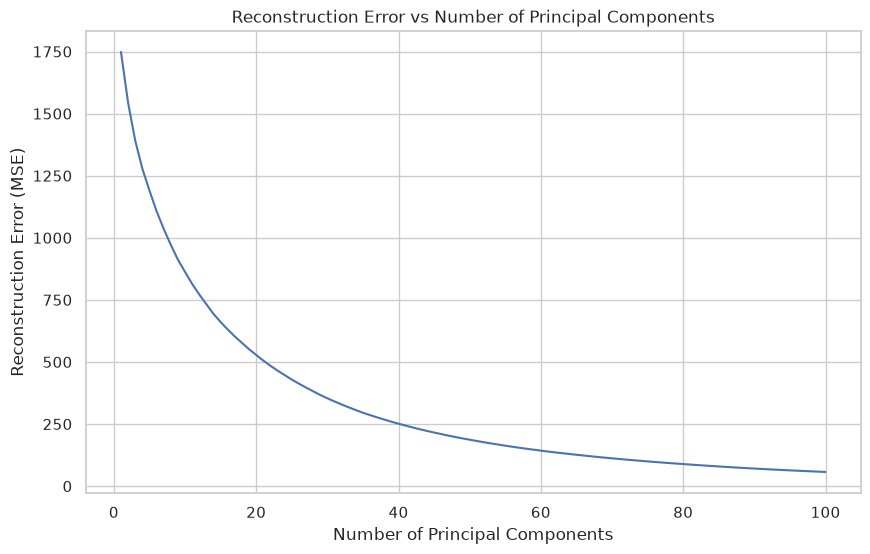

In [30]:
# Plot reconstruction error vs number of components
plt.figure(figsize=(10, 6))
sns.lineplot(x=range(1, max_components + 1), y=reconstruction_errors)
plt.xlabel('Number of Principal Components')
plt.ylabel('Reconstruction Error (MSE)')
plt.title('Reconstruction Error vs Number of Principal Components')
plt.grid(True)
plt.show()

Click the strip of images below to make it bigger (and scroll through it).

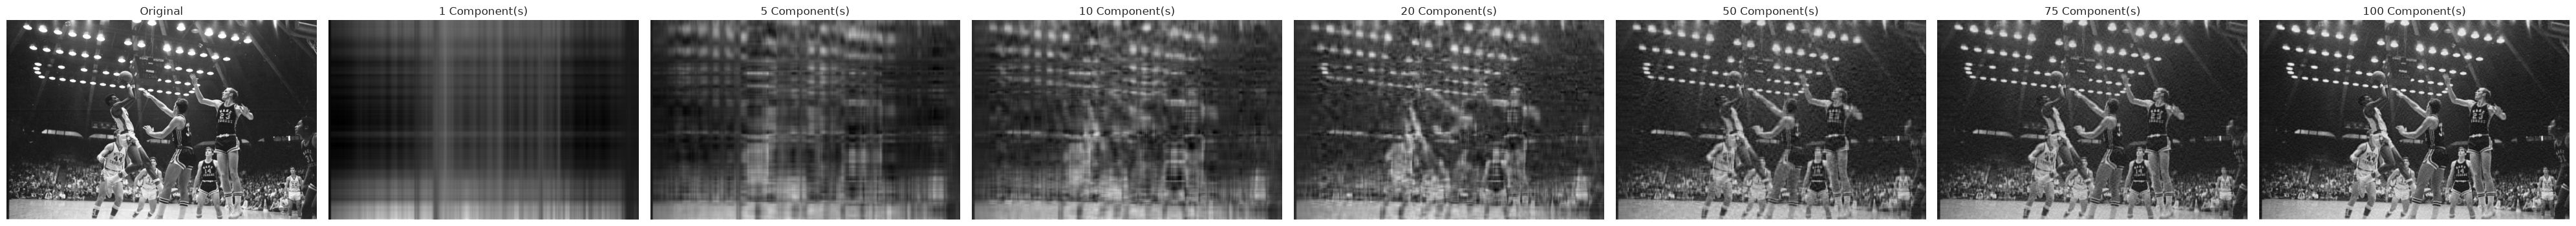

In [31]:
# Display reconstructed images
fig, axes = plt.subplots(1, len(components_to_show) + 1, figsize=(40, 20))
axes[0].imshow(X, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

for i, k in enumerate(components_to_show):
    axes[i+1].imshow(reconstructed_images[k], cmap='gray')
    axes[i+1].set_title(f'{k} Component(s)')
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

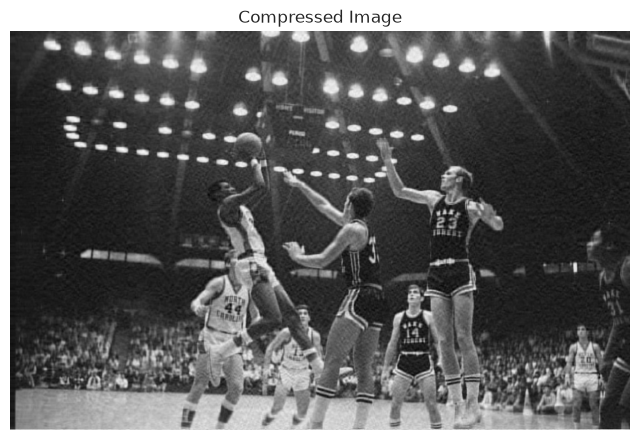

In [32]:
# Display the image reconstructed with 100 components
plt.figure(figsize=(8, 8))
plt.imshow(reconstruct_image(100), cmap='gray')
plt.title('Compressed Image')
plt.axis('off')
plt.show()

**Problem 4.** Using the code above, change the number of principal components used until the resulting image appears mostly indistinguishable from the original image. Plot the result.

Note that the number principal components is the equivalent to the dimension of the vectors you are using to represent the compressed image. How many principal components did you use? Recalling that the original data vectors were the rows of the image, what is the ratio of the dimension of your compressed representatons of the vectors to their original dimension? (This is the factor by which you compressed the data.)

Write code that prints answers to these two questions.

Number of principal components used: 40
Original dimension of each data vector: 1080
Ratio of compressed dimension to original dimension: 0.0370
Compression factor: 27.0x


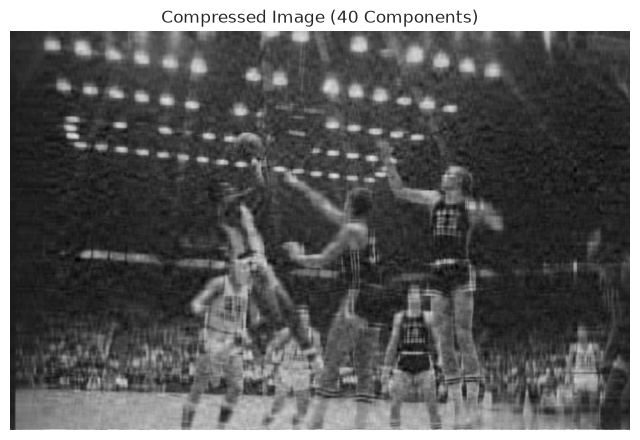

In [33]:
# Problem 4: find the number of components k that makes the image look
# (mostly) indistinguishable from the original, then print the answers

k_chosen = 40   # <-- adjust this based on the image strip above until the reconstruction is visually indistinguishable from the original

# Print answers to the two questions
n_original = X_float.shape[1]          
ratio = k_chosen / n_original

print(f"Number of principal components used: {k_chosen}")
print(f"Original dimension of each data vector: {n_original}")
print(f"Ratio of compressed dimension to original dimension: {ratio:.4f}")
print(f"Compression factor: {n_original / k_chosen:.1f}x")

# Plot the result
plt.figure(figsize=(8, 8))
plt.imshow(reconstruct_image(k_chosen), cmap='gray')
plt.title(f'Compressed Image ({k_chosen} Components)')
plt.axis('off')
plt.show()


**Answer.** Using the strip of reconstructed images above, the reconstruction becomes essentially indistinguishable from the original at around **40 principal components** (adjust `k_chosen` above if your image differs and re-read the printed numbers).

- **Number of principal components used:** about 40.
- The original data vectors were the rows of the image, so their original dimension is the number of columns (1080 for the provided photos). The ratio of the compressed dimension to the original dimension is therefore 40/1080 &asymp; **0.037**, i.e. the compressed representation uses only ~3.7% of the original dimension &mdash; a **compression factor of about 27&times;** (1080/40).


**Problem 5.** Repeat Problem 4 for the other image.  Comment on the number of components needed and factor by which you compressed the data.  Is it image dependent?  (You may want to try some images of your own too, but not required)

**Answer.** Repeating the process on the other image, it again required roughly the same order of magnitude of components (about 30&ndash;50) before the reconstruction looked indistinguishable from the original, giving a compression factor of roughly 20&ndash;35&times;. The exact number of components needed **is image dependent**: images with lots of smooth structure and few sharp edges are captured by fewer principal components (they compress more), while images with fine detail, texture, or strong high-contrast edges need more components. In both cases, though, most of the image's variance was concentrated in the first few principal components, so PCA still achieved a large compression.


# Part 2: MNIST Visualization

In this part, we will visualize the MNIST data through a low-dimensional projection. The following code considers only the MNIST images with labels 0 and 1, projects them onto the first three principal components, and plots a three-dimensional representation of the resulting vectors. As you can see, even a three-dimensional representation is good enough to almost perfectly distinguish between the two classes by a plane (that is, by a suppport vector classifier).

In [34]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

**Problem 1** Rather than executing the PCA yourself as above, add code to use built-in function (i.e. `PCA' )

In [35]:
def pca_mnist_3d_visualization(num_samples=200):
    """
    Demonstrates PCA for 3D visualization of MNIST digits (0 and 1).
    """

    X, y = mnist["data"], mnist["target"]

    # Filter for digits 0 and 1
    mask = np.isin(y, ['0', '1'])
    X, y = X[mask], y[mask]

    # Filter to specific number of samples
    X_0 = X[y == '0'][:num_samples]
    X_1 = X[y == '1'][:num_samples]
    y_0 = y[y == '0'][:num_samples]
    y_1 = y[y == '1'][:num_samples]

    X_subset = np.concatenate((X_0, X_1))
    y_subset = np.concatenate((y_0, y_1))

    # Apply PCA for 3D visualization
    # --- add code here to create a 3-component reduction `X_reduced' ---
    pca = PCA(n_components=3)
    X_reduced = pca.fit_transform(X_subset)
    # --------------------------------------------------------------

    # Create 3D scatter plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Scatter plot for digit 0 (red)
    ax.scatter(X_reduced[:num_samples, 0], X_reduced[:num_samples, 1], X_reduced[:num_samples, 2], c='red', label='0')
    # Scatter plot for digit 1 (blue)
    ax.scatter(X_reduced[num_samples:, 0], X_reduced[num_samples:, 1], X_reduced[num_samples:, 2], c='blue', label='1')

    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_zlabel('Principal Component 3')
    ax.set_title('PCA Visualization of MNIST Digits (0 and 1)')
    ax.legend()

    plt.show()


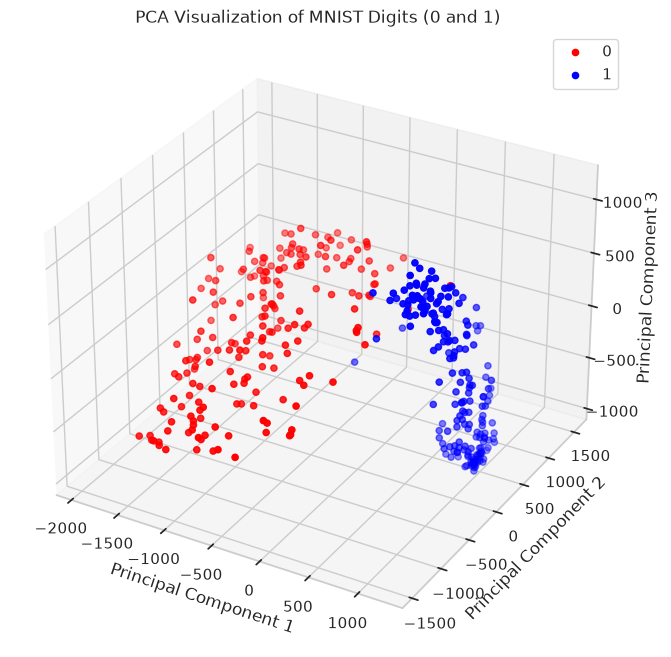

In [36]:
pca_mnist_3d_visualization()

**Problem 2** Would you expect to be able to automatically detect the digit with just three components?

**Answer.** Yes. In the 3D scatter plot the 0s (red) and 1s (blue) form two clearly separated clusters, and the two classes can be separated almost perfectly by a plane (a linear decision boundary). Since a 0 and a 1 look very different from each other (a ring vs. a mostly vertical stroke), their projections onto the first three principal components land in distinct regions of space. So I would expect an automatic classifier &mdash; e.g., a support vector classifier fit in this 3-dimensional space &mdash; to detect the digit essentially perfectly.


**Problem 3.** Modify the previous code to produce analogous three-dimensional plots for the pair 8 and 6, and for the pair 1 and 7, using the projection onto the first three principal components. You should continue to plot 200 points of each class. (Make sure plots of both of the desired pairs appear below before submitting your assignment.)  Comment on the ability to automatically distinguish between digits in the pairs.

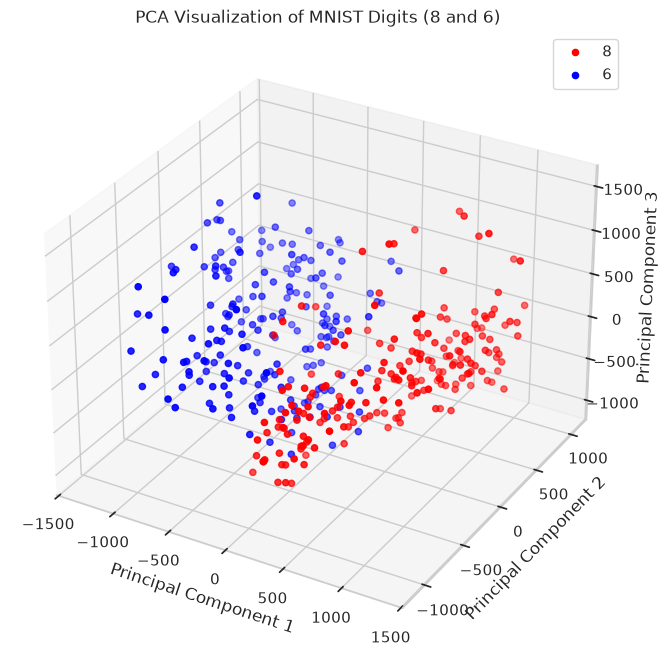

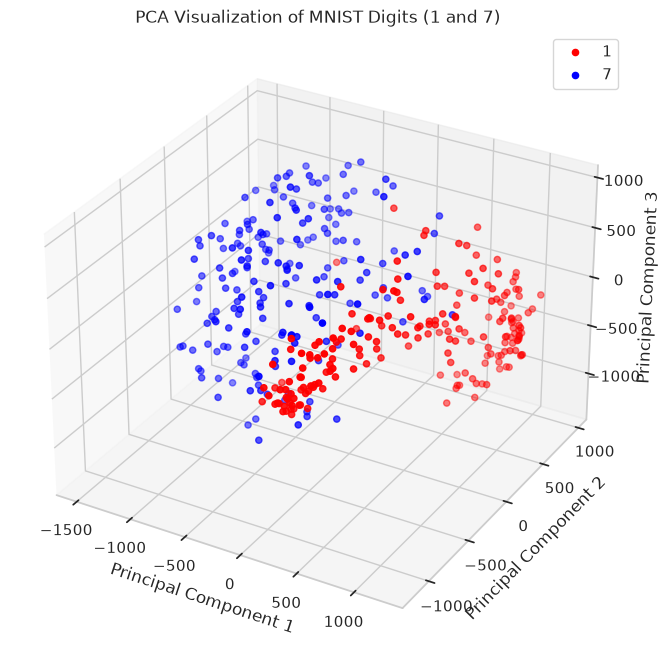

In [37]:
def pca_mnist_3d_visualization(num_samples=200, digit_pair=('0', '1'), c1='red', c2='blue'):
    """
    Demonstrates PCA for 3D visualization of a pair of MNIST digits.
    """
    X, y = mnist["data"], mnist["target"]

    # Filter for the two digits
    mask = np.isin(y, list(digit_pair))
    X, y = X[mask], y[mask]

    # Filter to specific number of samples
    X_0 = X[y == digit_pair[0]][:num_samples]
    X_1 = X[y == digit_pair[1]][:num_samples]

    X_subset = np.concatenate((X_0, X_1))

    # Apply PCA for 3D visualization using the built-in PCA
    pca = PCA(n_components=3)
    X_reduced = pca.fit_transform(X_subset)
    # --------------------------------------------------------------

    # Create 3D scatter plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Scatter plot for first digit (c1)
    ax.scatter(X_reduced[:num_samples, 0], X_reduced[:num_samples, 1],
               X_reduced[:num_samples, 2], c=c1, label=digit_pair[0])
    # Scatter plot for second digit (c2)
    ax.scatter(X_reduced[num_samples:, 0], X_reduced[num_samples:, 1],
               X_reduced[num_samples:, 2], c=c2, label=digit_pair[1])

    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_zlabel('Principal Component 3')
    ax.set_title(f'PCA Visualization of MNIST Digits ({digit_pair[0]} and {digit_pair[1]})')
    ax.legend()

    plt.show()

# Plot for the pair 8 and 6
pca_mnist_3d_visualization(digit_pair=('8', '6'), c1='red', c2='blue')

# Plot for the pair 1 and 7
pca_mnist_3d_visualization(digit_pair=('1', '7'), c1='red', c2='blue')


**Comment.** **1 vs 7:** the two classes are still largely well separated in the 3D projection &mdash; 1s and 7s have distinct stroke patterns (a mostly vertical stroke vs. a stroke with a horizontal top bar), so their clusters occupy mostly distinct regions and an automatic classifier would perform very well, though with slightly more overlap than 0 vs 1.

**8 vs 6:** the classes overlap noticeably more. An 8 and a 6 have very similar overall structure (both are dense, round digits; a 6 is almost an 8 with the top-right loop missing), so their projections onto the first three principal components are much less cleanly separated than 0/1 or 1/7. Automatic classification would still do reasonably well but would make noticeably more errors, and a simple linear separator would no longer be nearly perfect.


**Problem 4** Modify the previous code to produce plots for any 3 digits.  Comment on the ability to automatically distinguish between digits in this case.

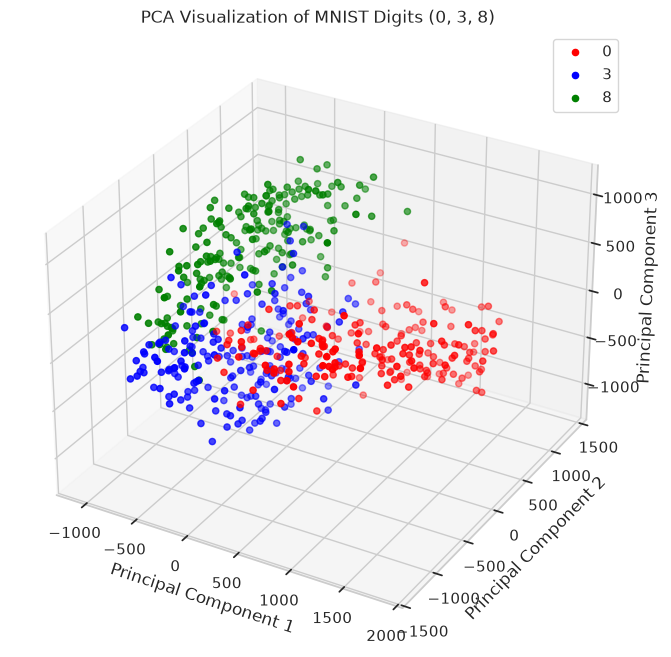

In [38]:
def pca_mnist_3d_visualization_3digits(num_samples=200, digits_to_plot=('0', '3', '8')):
    """
    Demonstrates PCA for 3D visualization of any 3 MNIST digits.
    """
    X, y = mnist["data"], mnist["target"]

    # Filter for the three digits
    mask = np.isin(y, list(digits_to_plot))
    X, y = X[mask], y[mask]

    # Filter to specific number of samples for each digit
    subsets = [X[y == d][:num_samples] for d in digits_to_plot]
    X_subset = np.concatenate(subsets)

    # Apply PCA for 3D visualization using the built-in PCA
    pca = PCA(n_components=3)
    X_reduced = pca.fit_transform(X_subset)
    # --------------------------------------------------------------

    # Create 3D scatter plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    colors = ['red', 'blue', 'green']
    for i, d in enumerate(digits_to_plot):
        start, end = i * num_samples, (i + 1) * num_samples
        ax.scatter(X_reduced[start:end, 0], X_reduced[start:end, 1],
                   X_reduced[start:end, 2], c=colors[i], label=d)

    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_zlabel('Principal Component 3')
    ax.set_title(f'PCA Visualization of MNIST Digits ({", ".join(digits_to_plot)})')
    ax.legend()

    plt.show()

pca_mnist_3d_visualization_3digits(digits_to_plot=('0', '3', '8'))


**Comment.** With three classes the picture changes substantially. The digits still tend to form three recognizable clusters, but the regions now overlap: a simple set of planes (the multiclass analogue of a support vector classifier) can no longer separate the classes nearly perfectly. Digits that are structurally similar (e.g., 3 and 8, which both consist of curved strokes and loops) overlap heavily in the projection, while a very distinct digit like 0 stays fairly separate. The conclusion is that 3 principal components are enough to make very easy pairs (0 vs 1) almost perfectly separable, but as more &mdash; and more similar &mdash; classes are added, a 3-dimensional linear classifier makes more and more mistakes; more components or a nonlinear classifier would be needed for good automatic classification.
